In [239]:
import utils
print(f"utils : {utils.__version__}")
from utils.structure import build_electrode, build_nanoribbon, build_reduced_device, find_nearest_atoms
from utils.plots import plot_with_center, mark_electrode# plotting
from utils.energies import hamiltonian, multi_LDOS_parallel, multi_LDOS
from utils import pretty_print_columns
from utils._wrappers import timeit


import sisl
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view
from tqdm.notebook import tqdm

import ipywidgets
from ipywidgets import interact
from fractions import Fraction


%reload_ext line_profiler


utils : 0.2.2


# Global parameters

In [240]:
ENERGIES = np.linspace(-2, 2, num=50)

# Benchmark full device: flake convergence
This is how I expect the final structure to converge when computing the LDOS from self-energies

loop:   0%|          | 0/4 [00:00<?, ?it/s]

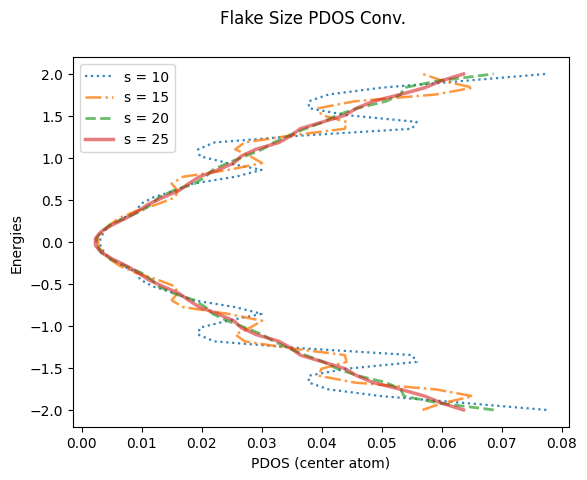

In [4]:
sizes = [10, 15, 20, 25]
fig, axes = plt.subplots()
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
LINESTYLE = [":", "-.", "--", "-"]
ALPHA = [0.9, 0.8, 0.7, 0.6]
LINEWIDTH = [2.5, 2.0, 1.8, 1.6][::-1]
for i, s in enumerate(tqdm(sizes, desc="loop")):
    pdos = make_benchmark(s, ENERGIES)
    axes.plot(pdos, ENERGIES, label=f"{s = }",
              alpha=ALPHA[i], color=COLORS[i],
              linestyle=LINESTYLE[i], lw=LINEWIDTH[i])

axes.set_xlabel("PDOS (center atom)")
axes.set_ylabel("Energies")
axes.legend()
fig.suptitle(f"Flake Size PDOS Conv.")
fig.savefig("figures/graphene_flake_PDOS_convergence.png")


In [4]:
def mark_electrode(lr_indices):
    """Helper function for plotting electrodes.
    Colors 'left' and 'right' electrodes using blue and red respectively.
    Scales the atom sizes to match opposing electrodes."""
    atoms_style = []
    for i, (l, r) in enumerate(zip(*lr_indices)):
        atoms_style += [{"atoms": l, "size": i*0.3 + 0.5, "color": "blue"}]
        atoms_style += [{"atoms": r, "size": i*0.3 + 0.5, "color": "red"}]
    return atoms_style

In [68]:
@timeit
def electrode_dos(ham, nk, energies):
    """compute DOS from built-ins
    
    Parameters
    ----------
    ham : Hamiltonian of shape (K, K)
        Hamiltonian in question 
    nk : int
        number of k points
    energies : ndarray of shape (N,)
        list of energies to compute the dos

    Returns
    -------
    dos : ndarray of shape (N,)
        density of state
    bs : ndarray of shape (M, N)
        bandstructure eigenvalues 
    lk : ndarray of shape (M,)
        scaled kpoints to linear values for use in plotting
    """
    dist = sisl.get_distribution(method="lorentzian", smearing=0.05)
    
    bz = sisl.MonkhorstPack(ham, [nk, 1, 1])
    kvecs = [[0,0,0], [0.5, 0, 0]]
    bands = sisl.BandStructure(ham, kvecs, 15, [r"$\Gamma$", "$K$"])
    lk, kticks, knames = bands.lineark(ticks=True)
    bs = bands.apply.array.eigh()
    dos = (bz.apply.average).eigenstate(wrap = lambda x: x.DOS(energies, distribution=dist)) 
    return dos, bs, (lk, kticks, knames)

## Infer center size

In [ ]:
# from itertools import product
# import os 
# def clear_console():
#     os.system('cls' if os.name == "nt" else "clear")

# ilist = range(0, 6)
# lengthlist = range(1, 4)
# center_sizelist = range(1, 5)
# trial_combinations = product(ilist, lengthlist, center_sizelist)
# trial_combinations
# def test_build(i, L, C):
#     W = lambda x: 5 + 4*x
    
#     elec = build_electrode(W(i), L)
#     ribbon = build_nanoribbon(elec, C)
#     device_ribbon, lr_idx = build_reduced_device(ribbon, elec, repeat=1)
#     atoms_style = mark_electrode(lr_idx)
#     return plot_with_center(device_ribbon, atoms_style=atoms_style)

# results = []
# for i, L, C in trial_combinations:
#     # clear_console()
#     print(f"{(i, L, C) = }")
#     test_build(i, L, C)
#     user_input = input("Is valid? (y/n/q) : ").strip().lower()
#     valid = user_input.startswith("y")
#     if user_input == "q":
#         print("stopping early")
#         break
#     if user_input not in ["y", "n"]:
#         print("wrong input.")
#         break
#     else:
#         results.append({"i": i,
#                         "L": L,
#                         "C": C,
#                         "valid": valid}
#         )
# # i = 0
# # width = 5 + 4*i

# import pandas as pd
# df = pd.DataFrame(results)
# df.to_csv("validity_ribbon.csv", index=False)


(i, L, C) = (0, 1, 1)
       Initial number of atoms: 30
 Atoms after removing overlaps: 30


/home/bastian/projects/QuantumTwistingMicroscope/QTM/utils/structure.py:123: UserWarning:


### Warning: The geometric center lies on bonds.



(i, L, C) = (0, 1, 2)
       Initial number of atoms: 40
 Atoms after removing overlaps: 40
(i, L, C) = (0, 1, 3)
       Initial number of atoms: 50
 Atoms after removing overlaps: 50


/home/bastian/projects/QuantumTwistingMicroscope/QTM/utils/structure.py:123: UserWarning:


### Warning: The geometric center lies on bonds.



(i, L, C) = (0, 1, 4)
       Initial number of atoms: 60
 Atoms after removing overlaps: 60
(i, L, C) = (0, 2, 1)
       Initial number of atoms: 60
 Atoms after removing overlaps: 60
(i, L, C) = (0, 2, 2)
       Initial number of atoms: 80
 Atoms after removing overlaps: 80
(i, L, C) = (0, 2, 3)
       Initial number of atoms: 100
 Atoms after removing overlaps: 100
(i, L, C) = (0, 2, 4)
       Initial number of atoms: 120
 Atoms after removing overlaps: 120
(i, L, C) = (0, 3, 1)
       Initial number of atoms: 90
 Atoms after removing overlaps: 90


...

(i, L, C) = (5, 1, 4)
       Initial number of atoms: 300
 Atoms after removing overlaps: 300
(i, L, C) = (5, 2, 1)
       Initial number of atoms: 300
 Atoms after removing overlaps: 300
(i, L, C) = (5, 2, 2)
       Initial number of atoms: 400
 Atoms after removing overlaps: 400
(i, L, C) = (5, 2, 3)
       Initial number of atoms: 500
 Atoms after removing overlaps: 500
(i, L, C) = (5, 2, 4)
       Initial number of atoms: 600
 Atoms after removing overlaps: 600
(i, L, C) = (5, 3, 1)
       Initial number of atoms: 450
 Atoms after removing overlaps: 450


/home/bastian/projects/QuantumTwistingMicroscope/QTM/utils/structure.py:123: UserWarning:


### Warning: The geometric center lies on bonds.



(i, L, C) = (5, 3, 2)
       Initial number of atoms: 600
 Atoms after removing overlaps: 600
(i, L, C) = (5, 3, 3)
       Initial number of atoms: 750
 Atoms after removing overlaps: 750


/home/bastian/projects/QuantumTwistingMicroscope/QTM/utils/structure.py:123: UserWarning:


### Warning: The geometric center lies on bonds.



(i, L, C) = (5, 3, 4)
       Initial number of atoms: 900
 Atoms after removing overlaps: 900


In [670]:
# import pandas as pd
# df = pd.read_csv("validity_ribbon.csv")
# print(df.head())
# df_valid = df[df["valid"] == True]
# print(f"{len(df_valid)} valid out of {len(df)} total")


In [680]:
# df_valid.plot(x="i", y="L", style=".")

import math
l = 5
g = math.gcd(l, 2)
mod = l // g

print(g)
print(mod)

1
5


In [778]:
def infer_centersize(l, i):
    """
    Given L and a starting i, find the smallest i >= given i
    such that C = 2*(1+i)/l is a positive integer.
    Returns (L, W, C).
    """
    if l < 1:
        raise ValueError("l must be at least 1")
    if i < 0:
        raise ValueError("i must be non-negative")
    
    # we want  L | (2*(i+1))  meaning 2(1+i) is divisible by L yielding an integer.
    # ("|" means an integer k satisfies 2*(i+1) = Lk)
    
    # so 2*(1+i) = 0 mod L -> i = -1 mod (L/gcd(L, 2))
    import math
    g = math.gcd(l, 2)
    spacing = l // g # modulus for i
    
    # solve for i = -1 (mod s), but Python want positives
    target = (-1) % spacing
    
    # print(f"{spacing = }")
    # print(f"{target = }")
    # print(f"{i = }")
    # print(f"{target - i = }")
    # print(f"{-1 % spacing = }")
    # print(f"{(target-i)%spacing = }")
    if i <= target:
        i = target
    else:
        print(f"{(l, i) = } are incompatbile. Increasing i.")
        i = i + ((target - i) % spacing)
    
    w = 5 + i*4
    c = 2*(1+i)//l # integer
    return l, w, c

In [780]:

infer_centersize(3, 3)

(l, i) = (3, 3) are incompatbile. Increasing i.


(3, 25, 4)

# Benchmark Electrode: self-energy method against built-in

In [86]:
i = 1
length = 2
width = 5 + 4*i
center_size = 2
__params__ribbon = f"{width}W_{length}L_{center_size}C"
print(f"{__params__ribbon = }")
electrode = build_electrode(width=width, length=length)
ribbon = build_nanoribbon(electrode=electrode, center_size=center_size)
device_ribbon, lr_idx_ribbon = build_reduced_device(ribbon, electrode, repeat=1)
# device_ribbon.write(f"structures/ribbon_{__params__ribbon}.xyz")
atoms_style = mark_electrode(lr_idx_ribbon)
device_ribbon.plot(axes="xy", atoms_style=atoms_style)

plot_with_center(device_ribbon, atoms_style=atoms_style)

__params__ribbon = '9W_2L_2C'
       Initial number of atoms: 144
 Atoms after removing overlaps: 144


In [ ]:
def plot_dos_band(device, nk, energies):
    """Plot the device band structure and DOS"""
    H = hamiltonian(device)
    dos, bands, k = electrode_dos(H, nk, energies)
    fig, axes = plt.subplots(1,2, sharey=True)
    fig.suptitle(f"Built-in calc L={length}, W={width}, C={center_size}")
    axes[0].set_title("Band structure")    
    axes[0].plot(k[0], bands)    
    axes[0].set_xlabel("$k$", size=15)
    axes[0].set_xticks(k[1])
    axes[0].set_xticklabels(k[2])
    
    axes[1].set_title("DOS")
    axes[1].plot(dos, energies, label="built-in DOS")
    axes[1].set_xlabel("DOS", size=15)
    
    axes[0].set_ylabel("E", size=15)
    fig.tight_layout()
    for ax in axes:
        ax.grid()
    
    return fig, axes

## Built-in calculations for bands and DOS

In [71]:
test, res = divmod(10, 3)
print(f"{test:02}: {res:02.3f}")

03: 1.000


func 'electrode_dos' with args : -not implemented-  ran in 0.0:0.0:1.605


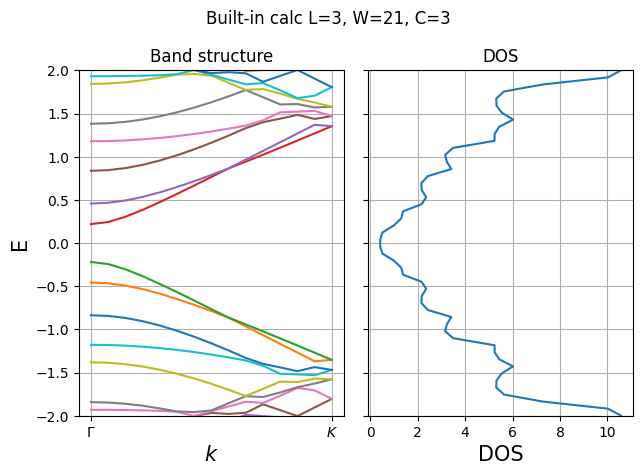

In [ ]:
_electrode = electrode.copy()
fig, axes = plot_dos_band(electrode, 100, ENERGIES)
minmax = 2
axes[0].set(ylim=(-minmax, minmax))
fig.savefig(f"figures/electrode_bands_DOS_{__params__ribbon}.png")

## Self-energy LDOS VS. built-in DOS 

In [ ]:
# Nk = 1
# all_ldos = multi_LDOS(device=device_ribbon, 
#                      electrode=electrode, 
#                      lr_indices=lr_idx_ribbon, 
#                      energies=ENERGIES, Nk=Nk, eta=1e-5, form="csc") # self-energy calc. LDOS NSC = [1,1,1]

# dos, bs, lk = electrode_dos(hamiltonian(device_ribbon), 100, ENERGIES) # assumes PBC - NSC=[3,1,1]

# np.savez(f"calculations/ribbon_ldos_{__params__ribbon}", energies=ENERGIES, 
#          ldos=all_ldos, dos=dos, bs=bs, lineark=lk[0], kxpos=lk[1], klab=lk[2])
# print(f"{__params__ribbon =}")


k-points:   0%|          | 0/1 [00:00<?, ?it/s]

Energy:   0%|          | 0/50 [00:00<?, ?it/s]

func 'electrode_dos' with args : -not implemented-  ran in 0.0:0.0:33.096


## Plotting LDOS VS. dos

Does not require to run previous cells

In [556]:
# w = 40
# l = 2
# c = 3
# Nk = 1
# PARAMS_ribbon = f"{w}W_{l}L_{c}C"
# DATA = np.load(f"calculations/ribbon_ldos_{PARAMS_ribbon}.npz")
# energies, ldos, dos, bs, ks, kpos, klabels = (DATA["energies"], DATA["ldos"], DATA["dos"], DATA["bs"], DATA["lineark"], DATA["kxpos"], DATA["klab"])
# device_ribbon = sisl.io.get_sile(f"structures/ribbon_{PARAMS_ribbon}.xyz").read_geometry()

In [557]:
# plot_with_center(device_ribbon,
#                 #  atoms_style=atoms_style
#                  )#

In [558]:
# def plot_ldos(kidx, site, fixed_scale, samefig=True):
#     print(ldos.shape)
#     """Plot LDOS from self-energy calculation with DOS from built-ins"""
    
#     X1 = ldos[kidx, :, site]
#     X2 = dos
    
#     # only used if fixed_scale=True
#     ymin, ymax = np.min([np.min(ldos), np.min(dos)]), np.max([np.max(ldos), np.max(dos)])
    
#     if samefig: # plot in the save figure
#         fig, axes = plt.subplots(1,1)
    
#         normalize = lambda arr: (arr - arr.mean()) / arr.std()
#         X1 = normalize(X1)
#         X2 = normalize(X2)
#         axes.plot(X1, energies, label="SE (LDOS)")
#         axes.plot(X2, energies, label="Built-in (DOS)")
#         axes.set_xlabel("DOS (normalized)")
#         axes.legend()
#         axes.set_ylabel("E")
#         axes.set_title("DOS for nanoribbon")
#         if fixed_scale:
#             # ymin, ymax = np.min([np.min(all_ldos), np.min(dos)]), np.max([np.max(all_ldos), np.max(dos)])
#             axes.set_xlim(-ymax*0.1, ymax*1.01)
    
#     else: # plot as subfigure
#         fig, axes = plt.subplots(1,2, sharey=True)
#         axes[0].plot(X1, energies)
#         axes[0].set_title("SE (LDOS)")
#         axes[0].set_ylabel("Energies")
        
#         axes[1].plot(X2, energies)
#         axes[1].set_title("Built-in (DOS)")
        
#         for ax in axes:
#             ax.set_xlabel("DOS")
#             if fixed_scale:
#                 ax.set_xlim(-ymax*0.1, ymax*1.01)
#     title_strlist = PARAMS_ribbon.split("_")
#     parse_number = lambda string: int("".join(ch for ch in string if ch.isdigit()))
#     for title_str in title_strlist:
#         if "W" in title_str:
#             w = parse_number(title_str)
#         elif "L" in title_str:
#             l = parse_number(title_str)
#         elif "C" in title_str:
#             c = parse_number(title_str)
#     fig.suptitle(f"L={l}, W={w}, C={c}")

# def interactive_params(device, Nk):
#     DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
#     # print(DEVICE_CENTER_ATOMS)

#     kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
#     options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
#     ks = ipywidgets.Dropdown(options=options, description="k")
#     # static = ipywidgets.fixed(all_ldos)
#     # sites = ipywidgets.IntSlider(min=left_idx[0].max()+1, max=right_idx[0].min()-1, value=left_idx[0].min(), description="Site")
#     sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")

#     scale = ipywidgets.Checkbox(value=False, description="Use fixed scale", indent=True)
#     same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
#     return ks, sites, scale, same


In [559]:
# ks, sites, scale, same = interactive_params(device_ribbon, Nk=Nk)
# interact(plot_ldos, kidx=ks, site=sites, fixed_scale=scale, samefig=same)


In [560]:
# atoms_style = mark_electrode(lr_idx_ribbon)
# plot_with_center(device_ribbon, 
#                 #  atoms_style=atoms_style
#                  )

# Convergence for device: Reduced structure (3 arms)

In [ ]:
i = 0
length = 2

length, width, center_size = infer_centersize(length, i)
__params__device = f"{length}L_{width}W_{center_size}C"
electrode = build_electrode(width=width, length=length)
ribbon = build_nanoribbon(electrode=electrode, center_size=center_size)
device, lr_idx_device = build_reduced_device(ribbon, electrode, repeat=3)
print(f"{__params__device.split("_")}")
atoms_style = mark_electrode(lr_idx_device)

plot_with_center(device, atoms_style=atoms_style)

       Initial number of atoms: 180
 Atoms after removing overlaps: 144
['2L', '5W', '1C']


In [470]:
Nk = 1
device.write(f"structures/device_{__params__device}.xyz")
all_ldos = multi_LDOS(device=device, 
                     electrode=electrode, 
                     lr_indices=lr_idx_device, 
                     energies=ENERGIES, Nk=Nk, eta=1e-5, form="csc")

# dos, bs, lk = electrode_dos(hamiltonian(device), 100, ENERGIES)

np.savez(f"calculations/device_ldos_{__params__device}", energies=ENERGIES, ldos=all_ldos, lr_idx = lr_idx_device
        #  dos=dos, bs=bs, lineark=lk[0], kxpos=lk[1], klab=lk[2]
         )
print(f"saved with parameters : {__params__device}")

k-points:   0%|          | 0/1 [00:00<?, ?it/s]

Energy:   0%|          | 0/50 [00:00<?, ?it/s]

saved with parameters : 17W_3L_4C


In [580]:
def load_datastructure(dims=(1,5,2)):
    l, w, c = dims
    params_string = f"{l}L_{w}W_{c}C"
    DATA = np.load(f"calculations/device_ldos_{params_string}.npz")
    device = sisl.io.get_sile(f"structures/device_{params_string}.xyz").read_geometry()
    energies, ldos, lr_idx = DATA["energies"], DATA["ldos"], DATA["lr_idx"]
    print(f"params : (L, W, C) = {dims}")
    return device, energies, ldos, lr_idx, params_string
    

In [609]:
l = 3
w = 13
c = 2
device, energies, ldos, lr_idx, PARAMS = load_datastructure(dims=(l,w,c))
# PARAMS = f"{l}L_{w}W_{c}C"
# DATA = np.load(f"calculations/device_ldos_{PARAMS}.npz")
# energies, ldos, lr_idx = DATA["energies"], DATA["ldos"], DATA["lr_idx"]
# device = sisl.io.get_sile(f"structures/device_{PARAMS}.xyz").read_geometry()

atoms_style = mark_electrode(lr_idx)
plot_with_center(device, atoms_style=atoms_style)

params : (L, W, C) = (3, 13, 2)


## Plotting LDOS VS. DOS*
*DOS is likely not right - calculated assuming 'pristine'

In [582]:
def plot_ldos(kidx, site, fixed_scale, samefig=True):
    print(ldos.shape)
    """Plot LDOS from self-energy calculation with DOS from built-ins"""
    
    X1 = ldos[kidx, :, site]
    # X2 = dos
    
    # only used if fixed_scale=True
    # ymin, ymax = np.min([np.min(ldos), np.min(dos)]), np.max([np.max(ldos), np.max(dos)])
    
    if samefig: # plot in the save figure
        fig, axes = plt.subplots(1,1)
    
        normalize = lambda arr: (arr - arr.mean()) / arr.std()
        X1 = normalize(X1)
        # X2 = normalize(X2)
        axes.plot(X1, energies, label="SE (LDOS)")
        # axes.plot(X2, energies, label="Built-in (DOS)")
        axes.set_xlabel("DOS (normalized)")
        axes.legend()
        axes.set_ylabel("E")
        axes.set_title("DOS for nanoribbon")
        if fixed_scale:
            # ymin, ymax = np.min([np.min(all_ldos), np.min(dos)]), np.max([np.max(all_ldos), np.max(dos)])
            # axes.set_xlim(-ymax*0.1, ymax*1.01)
            pass
    
    else: # plot as subfigure
        fig, axes = plt.subplots(1,2, sharey=True)
        axes[0].plot(X1, energies)
        axes[0].set_title("SE (LDOS)")
        axes[0].set_ylabel("Energies")
        
        # axes[1].plot(X2, energies)
        axes[1].set_title("Built-in (DOS)")
        
        for ax in axes:
            ax.set_xlabel("DOS")
            if fixed_scale:
                # ax.set_xlim(-ymax*0.1, ymax*1.01)
                pass
    title_strlist = PARAMS.split("_")
    parse_number = lambda string: int("".join(ch for ch in string if ch.isdigit()))
    for title_str in title_strlist:
        if "W" in title_str:
            w = parse_number(title_str)
        elif "L" in title_str:
            l = parse_number(title_str)
        elif "C" in title_str:
            c = parse_number(title_str)
    fig.suptitle(f"L={l}, W={w}, C={c}")

def interactive_params(device, Nk):
    DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    print(DEVICE_CENTER_ATOMS)

    kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
    options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
    ks = ipywidgets.Dropdown(options=options, description="k")
    sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")

    scale = ipywidgets.Checkbox(value=False, description="Use fixed scale", indent=True)
    same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
    return ks, sites, scale, same


In [583]:
ks, sites, scale, same = interactive_params(device, Nk=Nk)
interact(plot_ldos, kidx=ks, site=sites, fixed_scale=scale, samefig=same)

[21 19 23 16 20 18]


warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(kidx, site, fixed_scale, samefig=True)>

## Plot LDOS pr. energy (interactive)

In [503]:
from sisl.viz.processors.math import normalize
def scale_by_ldos(ldos, Eidx, atoms_style = None):
    scaling = lambda E: 10*E + 0.1
    Nk, NE, Ns = ldos.shape
    norm_ldos = normalize(ldos)
    style = {"atoms": range(Ns),
             "size": scaling(norm_ldos[0, Eidx, :])}
    if atoms_style is None:
        atoms_style = []
    
    atoms_style.append(style)
    return atoms_style
    
style = scale_by_ldos(ldos, 0, atoms_style)

In [485]:
print(PARAMS)
_atoms_style = mark_electrode(lr_idx)

def proj_ldos(Eidx):
    _style = scale_by_ldos(ldos, Eidx, _atoms_style)
    fig = device.plot(axes="xy", atoms_style=_style, backend="matplotlib", show_cell=False)
    fig.show()
    # return fig

# idxs = ipywidgets.Dropdown(options=range(ENERGIES.shape[0]), description="E")
idxs = ipywidgets.IntSlider(min=0, max=len(ENERGIES)-1, description="E")
interact(proj_ldos, Eidx=idxs)

5W_1L_2C


interactive(children=(IntSlider(value=0, description='E', max=49), Output()), _dom_classes=('widget-interact',…

<function __main__.proj_ldos(Eidx)>